In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import PIL

from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix

import os
from pathlib import Path
import random
from collections import OrderedDict
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchvision.models import vit_b_16, ViT_B_16_Weights


In [18]:
IMAGE_PATH = Path("/Users/devayushrout/Desktop/MedWaste Guardian/dataset")

IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

Total Images = 6156


In [19]:
CLASSES = os.listdir(IMAGE_PATH)
CLASSES = sorted(CLASSES)

print(f"Total Classes = {len(CLASSES)}:\n")
for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    print(f'* {label}: {len(total_images_class)} images')

Total Classes = 12:

* (BT) Body Tissue or Organ: 474 images
* (GE) Glass equipment-packaging 551: 551 images
* (ME) Metal equipment -packaging: 426 images
* (OW) Organic wastes: 583 images
* (PE) Plastic equipment-packaging: 558 images
* (PP) Paper equipment-packaging: 457 images
* (SN) Syringe needles: 513 images
* Gauze: 510 images
* Gloves: 543 images
* Mask: 529 images
* Syringe: 473 images
* Tweezers: 539 images


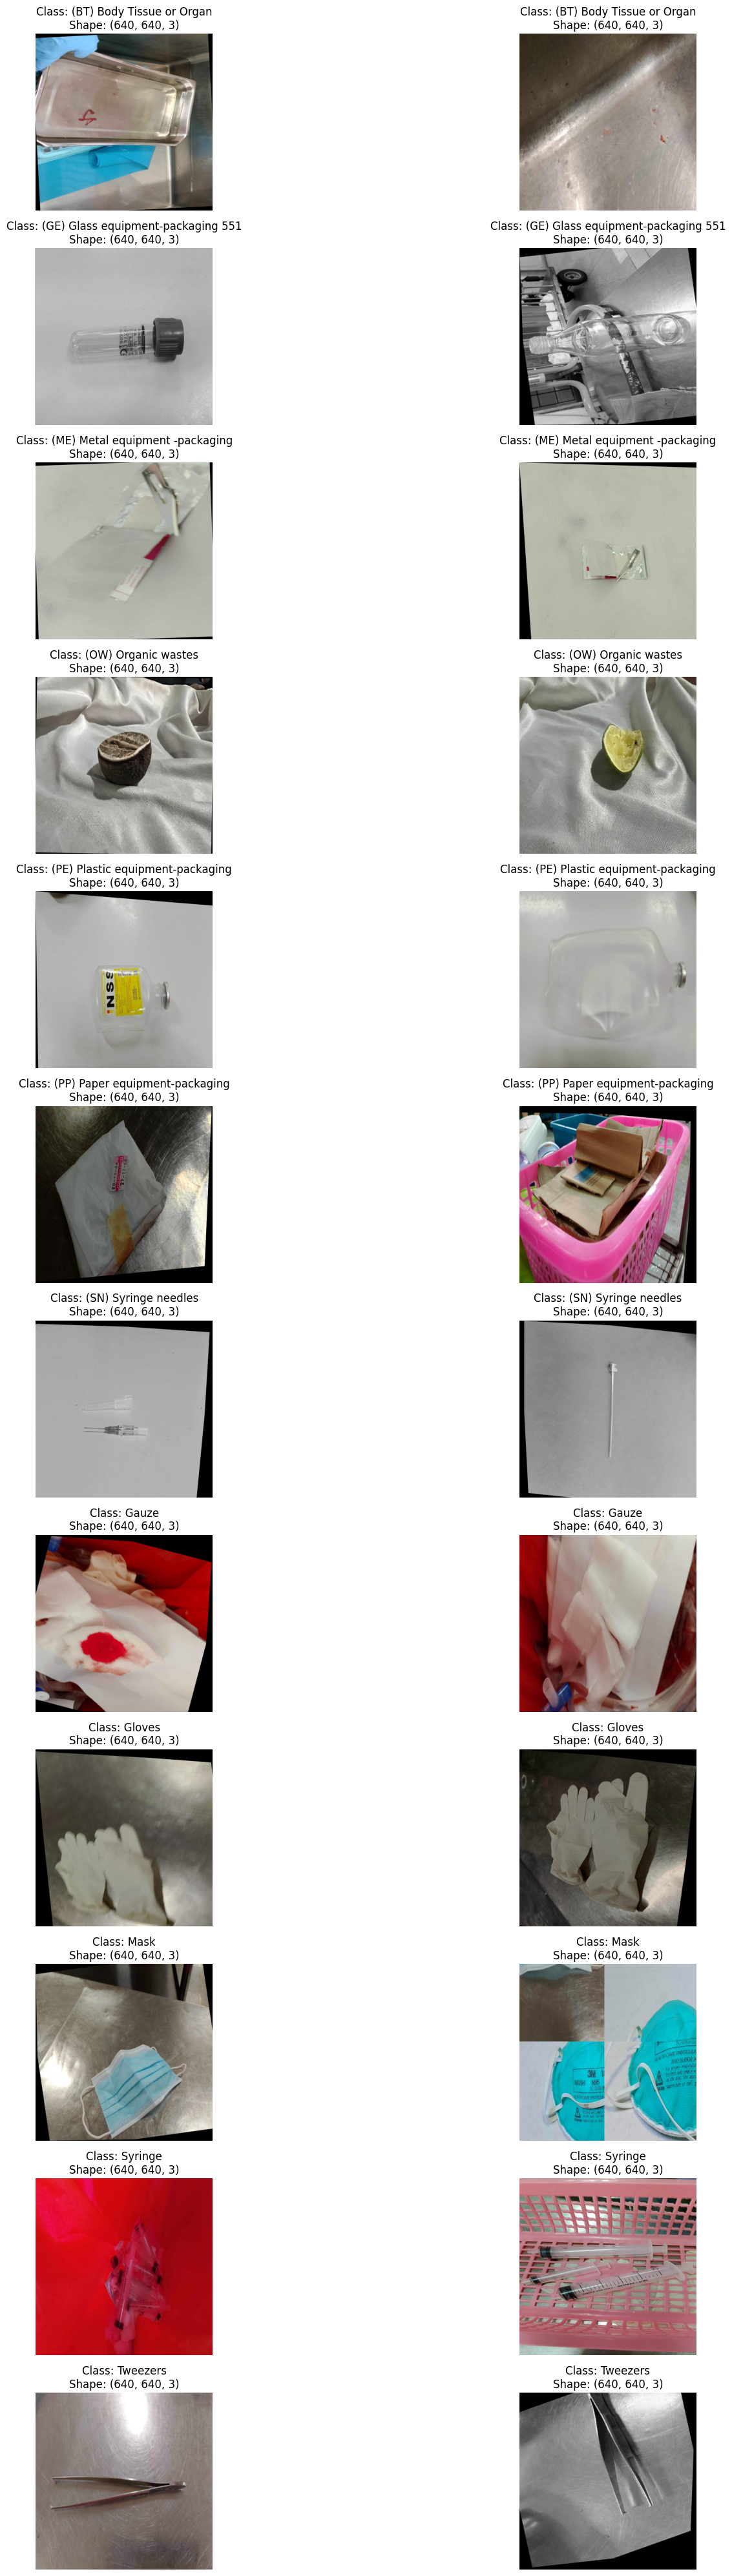

In [20]:
NUM_IMAGES = 2

fig,ax = plt.subplots(nrows = len(CLASSES), ncols = NUM_IMAGES, figsize = (20,40))

p = 0

for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    total_selected = random.choices(total_images_class, k = NUM_IMAGES)
    
    for i,img_path in enumerate(total_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[p,i].imshow(img_rgb)
        ax[p,i].axis('off')
        ax[p,i].set_title(f'Class: {label}\nShape: {img_rgb.shape}')
        
    p += 1
    
fig.tight_layout()
fig.show()

In [21]:
images_path_train = list()
labels_train = list()

images_path_test = list()
labels_test = list()

for i in IMAGE_PATH_LIST:
    if i.parent.stem == 'Train images':
        images_path_train.append(i)
        labels_train.append(i.parent.parent.stem)
        
    else:
        images_path_test.append(i)
        labels_test.append(i.parent.parent.stem)

In [22]:
data_train = pd.DataFrame({'Image':images_path_train, 'Label':labels_train})
data_train.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [23]:
data_testing = pd.DataFrame({'Image':images_path_test, 'Label':labels_test})
data_testing.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [24]:
SEED = 42

data_training, data_validation = tts(data_train, test_size = 0.3, random_state = SEED, 
                                    shuffle = True)

print(data_training.shape), print(data_validation.shape)

(3432, 2)
(1471, 2)


(None, None)